In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, _), (X_test, _) = mnist.load_data()

X_train_np = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255.0
X_test_np = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255.0

print("Training data shape:", X_train_np.shape)
print("Testing data shape:", X_test_np.shape)

C:\Users\Varun\AppData\Roaming\Python\Python310\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Training data shape: (60000, 784)
Testing data shape: (10000, 784)


# PCA

In [2]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

pca = PCA(n_components=32, random_state=42)

X_train_pca = pca.fit_transform(X_train_np)
X_test_pca = pca.transform(X_test_np)

X_test_pca_recon = pca.inverse_transform(X_test_pca)

pca_mse = mean_squared_error(X_test_np, X_test_pca_recon)

print("PCA Components:", pca.n_components_)
print("PCA Reconstruction MSE:", pca_mse)

PCA Components: 32
PCA Reconstruction MSE: 0.016828224062919617


# Autoencoder

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

autoencoder = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(32, activation="linear", name="bottleneck_latent"),
    
    Dense(128, activation="relu"),
    Dense(256, activation="relu"),
    Dense(784, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("Training Autoencoder...")
history = autoencoder.fit(
    X_train_np, X_train_np,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

X_test_ae_recon = autoencoder.predict(X_test_np)

ae_mse = mean_squared_error(X_test_np, X_test_ae_recon)
print("Autoencoder Reconstruction MSE:", ae_mse)

Training Autoencoder...
Epoch 1/10


C:\Users\Varun\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0221 - val_loss: 0.0156
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0147 - val_loss: 0.0139
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0132 - val_loss: 0.0128
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0124 - val_loss: 0.0122
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0118 - val_loss: 0.0116
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0114 - val_loss: 0.0113
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0110 - val_loss: 0.0111
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0107 - val_loss: 0.0108
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0105 - val_loss: 0.0106
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0103 - val_loss: 0.0103
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step
Autoencoder Reconstruction MSE: 0.010136591270565987


In [4]:
print("MSE Comparison")
print(f"PCA MSE:         {pca_mse:.6f}")
print(f"Autoencoder MSE: {ae_mse:.6f}")

MSE Comparison
PCA MSE:         0.016828
Autoencoder MSE: 0.010137


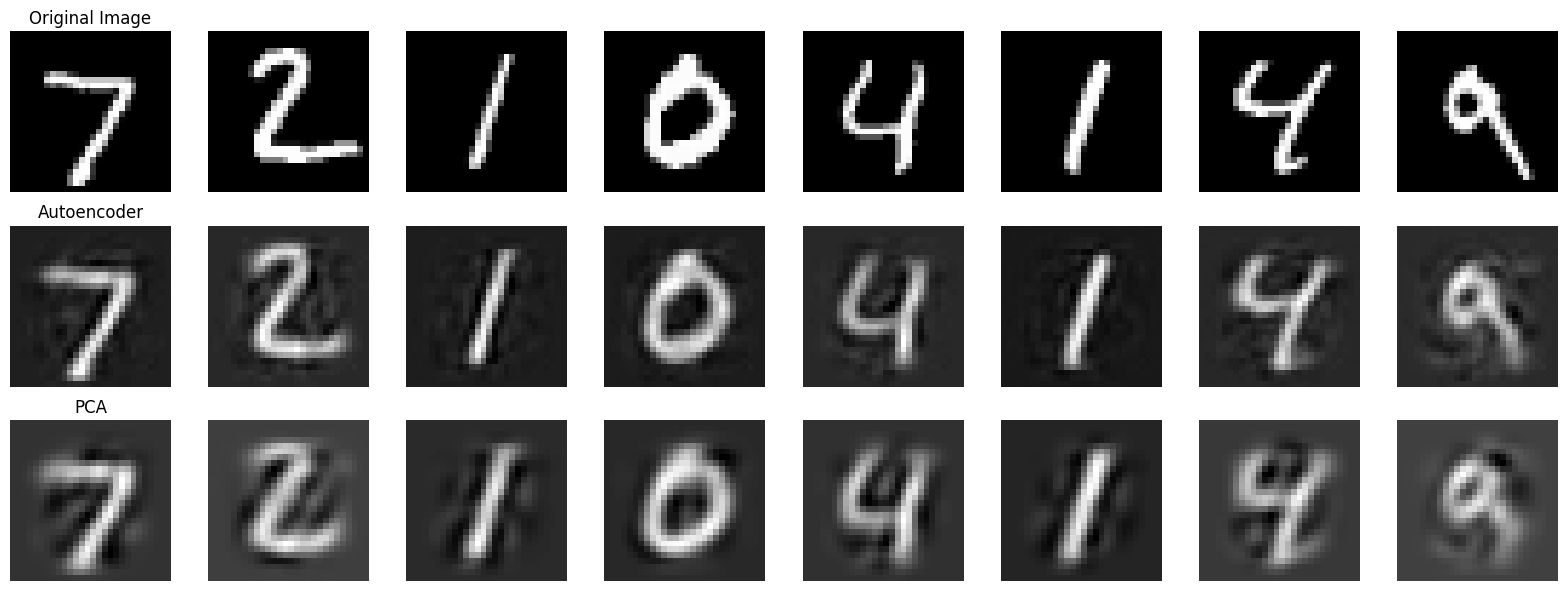

In [5]:
n_images = 8
plt.figure(figsize=(16, 6))

for i in range(n_images):
    ax = plt.subplot(3, n_images, i + 1)
    plt.imshow(X_test_np[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Original Image")

    ax = plt.subplot(3, n_images, i + 1 + n_images)
    plt.imshow(X_test_ae_recon[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Autoencoder")
        
    ax = plt.subplot(3, n_images, i + 1 + 2 * n_images)
    plt.imshow(X_test_pca_recon[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("PCA")

plt.tight_layout()
plt.show()